In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Soil_image_dataset"

In [ ]:
import os

for folder in os.listdir(dataset_path):
    print(folder)

Yellow_Soil
Black_Soil
Laterite_Soil
Alluvial_Soil
Red_Soil


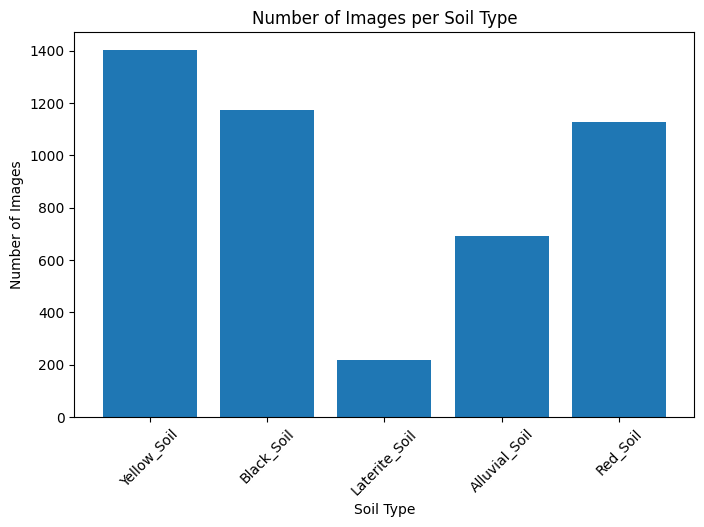

In [ ]:
import matplotlib.pyplot as plt
import os

folders = os.listdir(dataset_path)

counts = []

for folder in folders:

    folder_path = os.path.join(dataset_path, folder)

    counts.append(len(os.listdir(folder_path)))

plt.figure(figsize=(8,5))

plt.bar(folders, counts)

plt.title("Number of Images per Soil Type")

plt.xlabel("Soil Type")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(

    dataset_path,

    target_size=img_size,

    batch_size=batch_size,

    class_mode='categorical',

    subset='training'
)

val_data = datagen.flow_from_directory(

    dataset_path,

    target_size=img_size,

    batch_size=batch_size,

    class_mode='categorical',

    subset='validation'
)

Found 3691 images belonging to 5 classes.
Found 920 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn = Sequential()

# First Convolution Layer
cnn.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

cnn.add(MaxPooling2D(2,2))

# Second Layer
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D(2,2))

# Third Layer
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D(2,2))

# Flatten Layer
cnn.add(Flatten())

# Dense Layers
cnn.add(Dense(128,activation='relu'))

cnn.add(Dropout(0.5))

# Output Layer (5 classes)
cnn.add(Dense(5,activation='softmax'))

cnn.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn.fit(

    train_data,

    validation_data=val_data,

    epochs=15
)

Epoch 1/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 2670s 23s/step - accuracy: 0.8637 - loss: 0.4466 - val_accuracy: 0.8837 - val_loss: 0.3664
Epoch 2/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 562s 5s/step - accuracy: 0.9556 - loss: 0.1355 - val_accuracy: 0.9185 - val_loss: 0.2688
Epoch 3/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 562s 5s/step - accuracy: 0.9613 - loss: 0.1063 - val_accuracy: 0.9152 - val_loss: 0.3407
Epoch 4/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 593s 5s/step - accuracy: 0.9648 - loss: 0.1101 - val_accuracy: 0.8783 - val_loss: 0.5218
Epoch 5/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 562s 5s/step - accuracy: 0.9661 - loss: 0.1091 - val_accuracy: 0.9402 - val_loss: 0.2401
Epoch 6/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 557s 5s/step - accuracy: 0.9764 - loss: 0.0954 - val_accuracy: 0.7652 - val_loss: 1.5633
Epoch 7/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 574s 5s/step - accuracy: 0.9707 - loss: 0.0938 - val_accuracy: 0.9457 - val_loss: 0.2060
Epoch 8/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 601s 5s/step - accuracy: 0.9745 - loss: 0.0850 - val_ac

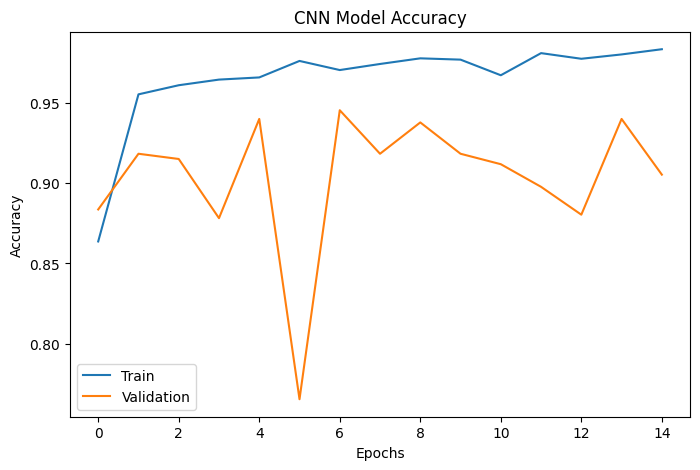

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Model Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
cnn.save(
    "/content/drive/MyDrive/soil_cnn_model.h5"
)

print("CNN model saved successfully!")

CNN model saved successfully!


29/29 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step


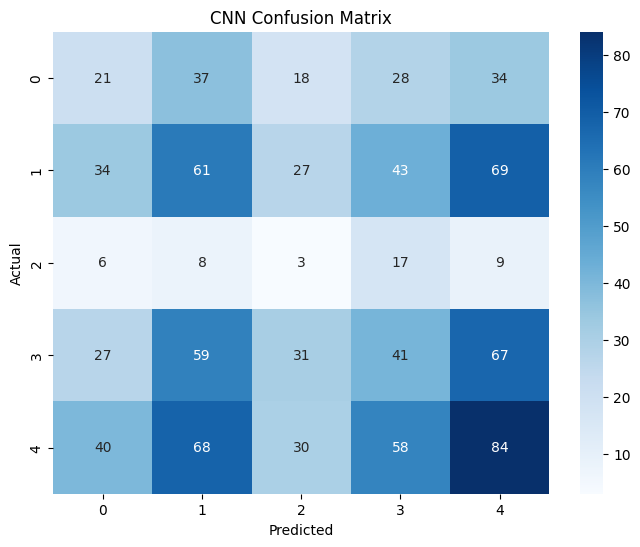

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
Y_pred = cnn.predict(val_data)

y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Class names
class_names = list(train_data.class_indices.keys())

def predict_image(img_path):

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array/255

    prediction = cnn.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    return predicted_class

In [ ]:
predict_image(
"/content/drive/MyDrive/soil.jpeg"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


'Black_Soil'

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [ ]:
base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False